# Generative Shape VAE: Interactive Sampling Demo

This notebook trains the sparse voxel shape VAE from [`examples/shape_vae.py`](../examples/shape_vae.py)
(the fvdb analog of MinkowskiEngine's `examples/vae.py`) and then explores its latent space interactively:
reconstructing shapes, sampling novel shapes from the prior, and interpolating between shapes.

The model is built from three fvdb pieces:

- **Generative transposed convolutions** — `fvdb.ConvolutionPlan.from_grid_batch_transposed(..., target_grid=None)`
  generates the complete (uncropped) transposed support, so the decoder can *create new voxel coordinates*
  (the `MinkowskiGenerativeConvolutionTranspose` analog).
- **`fvdb.nn.Prune`** — trims the generated topology with a per-voxel keep mask predicted by a classifier at
  each level (the `MinkowskiPruning` analog).
- A **ground-truth pyramid** built with `GridBatch.conv_grid(2, 2)` supplies per-level occupancy targets.

Training takes about 1–2 minutes on a GPU. See the module docstring of `examples/shape_vae.py` for the full
MinkowskiEngine-to-fvdb mapping and design notes.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import torch
import tqdm

# Reuse the data pipeline, model, and losses from examples/shape_vae.py.
repo_root = next(p for p in (pathlib.Path.cwd() / "..", pathlib.Path.cwd()) if (p / "examples" / "shape_vae.py").exists())
sys.path.insert(0, str((repo_root / "examples").resolve()))
import shape_vae as sv

torch.random.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## The dataset

Six bundled meshes (four cars, the dragon, and the happy Buddha), each voxelized to a sparse grid at
resolution 64 inside the unit cube. The whole "dataset" is one `GridBatch`, and the input features are
just a constant 1 per voxel — the network learns *topology*, not appearance.

In [2]:
gt_grid = sv.prepare_shapes(device)
gt_pyramid = sv.build_gt_pyramid(gt_grid)
input_features = gt_grid.jagged_like(torch.ones(gt_grid.total_voxels, 1, device=device))
shape_names = ["car 1", "car 2", "car 3", "car 4", "dragon", "happy"]
print(f"{gt_grid.grid_count} shapes, per-shape voxel counts: {gt_grid.num_voxels.tolist()}")

6 shapes, per-shape voxel counts: [8031, 9048, 8119, 5854, 8559, 6782]


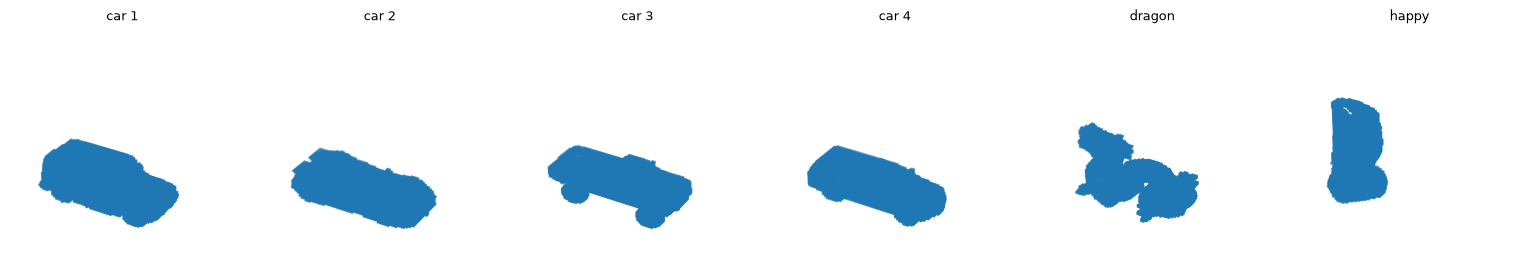

In [3]:
def plot_grids(grids_and_titles, point_size=1.0, panel_size=2.6):
    """Scatter the voxel centers of each (GridBatch, batch_index, title) triple in a row of 3D axes."""
    n = len(grids_and_titles)
    fig = plt.figure(figsize=(panel_size * n, panel_size))
    for i, (grid, b, title) in enumerate(grids_and_titles):
        ax = fig.add_subplot(1, n, i + 1, projection="3d")
        if grid.num_voxels_at(b) > 0:
            pts = grid.voxel_to_world(grid.ijk.float())[b].jdata.cpu().numpy()
            ax.scatter(pts[:, 0], pts[:, 2], pts[:, 1], s=point_size)
        ax.set_title(title, fontsize=9)
        ax.set_xlim(0, 1), ax.set_ylim(0, 1), ax.set_zlim(0, 1)
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()


plot_grids([(gt_grid, b, shape_names[b]) for b in range(gt_grid.grid_count)])

## Training

The encoder strides each shape down four levels and global-average-pools into a 128-dimensional latent
(`mu`, `logvar`). The decoder broadcasts a latent over a dense $4^3$ "neck" grid (plus a learned positional
embedding) and then alternates generative transposed convolution → occupancy classifier → `Prune` for four
levels back to full resolution. While training, the keep mask is teacher-forced with the ground truth
(`keep |= target`), exactly as in MinkowskiEngine. The loss is per-level binary cross-entropy plus a
down-weighted KL term.

In [4]:
model = sv.ShapeVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=sv.LEARNING_RATE)

model.train()
for iteration in tqdm.trange(sv.NUM_ITERATIONS, desc="training"):
    logits, targets, _, _, mu, logvar = model(input_features, gt_grid, gt_pyramid)
    loss, bce, kld = sv.vae_loss(logits, targets, mu, logvar)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print(f"final loss {loss.item():.4f} (bce {bce.item():.4f}, kld {kld.item():.4f})")

final loss 0.0058 (bce 0.0034, kld 0.2453)


## Reconstructions

Encode every training shape and decode from `z = mu` with **no teacher forcing** — the decoder keeps only
the voxels its classifiers predict.

reconstruction IoU vs ground truth: 0.999


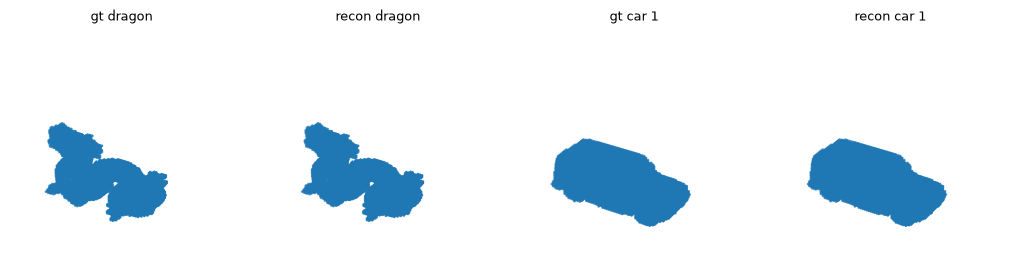

In [5]:
model.eval()
with torch.no_grad():
    mu, _ = model.encoder(input_features, gt_grid)
    _, _, _, recon_grid = model.decoder(mu, None)
print(f"reconstruction IoU vs ground truth: {sv.grid_iou(recon_grid, gt_grid):.3f}")

plot_grids(
    [(gt_grid, 4, "gt dragon"), (recon_grid, 4, "recon dragon"), (gt_grid, 0, "gt car 1"), (recon_grid, 0, "recon car 1")]
)

## Sampling novel shapes from the prior

Because the decoder never sees the encoder's topology (no skip connections), we can decode latents drawn
from the prior, $z \sim \mathcal{N}(0, I)$, and get novel shapes. With only six training shapes the prior
samples land between memorized modes — with a real dataset (e.g. ModelNet40 chairs, as in MinkowskiEngine's
`vae.py`) this is where genuinely new shapes appear.

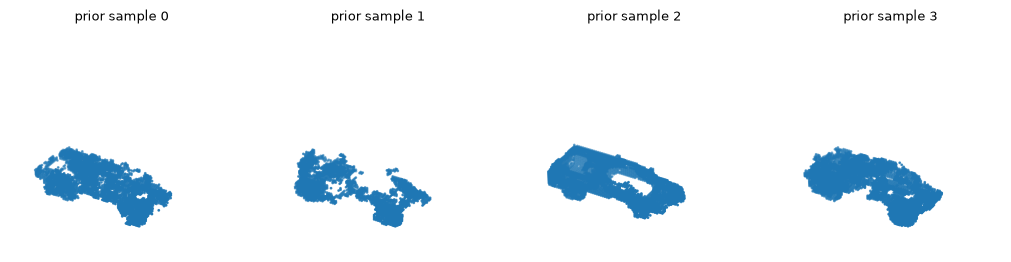

In [6]:
def decode_latents(z: torch.Tensor):
    """Decode a (batch, LATENT_DIM) tensor of latents into a GridBatch of generated topologies."""
    with torch.no_grad():
        _, _, _, grid = model.decoder(z, None)
    return grid


z = torch.randn(4, sv.LATENT_DIM, device=device)
samples = decode_latents(z)
plot_grids([(samples, b, f"prior sample {b}") for b in range(samples.grid_count)])

## Latent interpolation

Walk a straight line between two shapes' latents and decode each step. All the steps are decoded in one
batched call — the generated `GridBatch` simply has one grid per interpolation step.

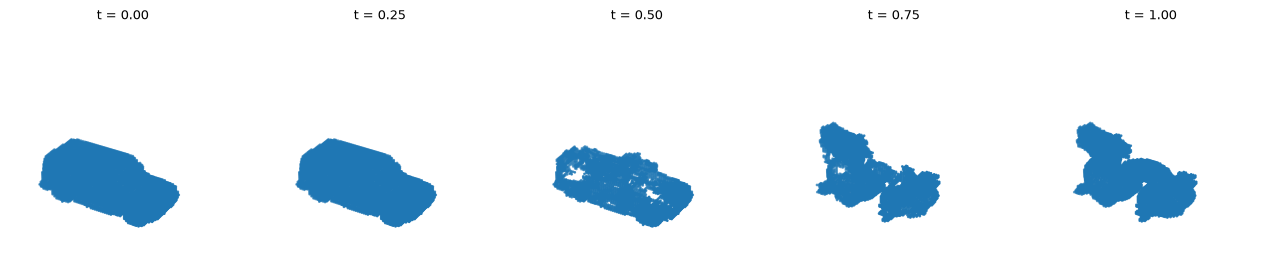

In [7]:
def interpolate(source: int, target: int, num_steps: int = 5):
    t = torch.linspace(0.0, 1.0, num_steps, device=device).unsqueeze(1)
    grids = decode_latents((1.0 - t) * mu[source] + t * mu[target])
    plot_grids([(grids, i, f"t = {t[i].item():.2f}") for i in range(num_steps)])


interpolate(source=0, target=4)  # car 1 -> dragon

## Interactive latent explorer

If `ipywidgets` is installed (it ships with the `fvdb_learn` environment), the cell below gives you live
controls: pick two shapes, blend between them, and add prior noise. Each slider move decodes a fresh
topology through the generative decoder. Without `ipywidgets` (e.g. in CI), a single static frame is shown
instead.

ipywidgets is not installed - showing a single static frame instead.
Install it (`pip install ipywidgets`) and re-run this cell for live sliders.


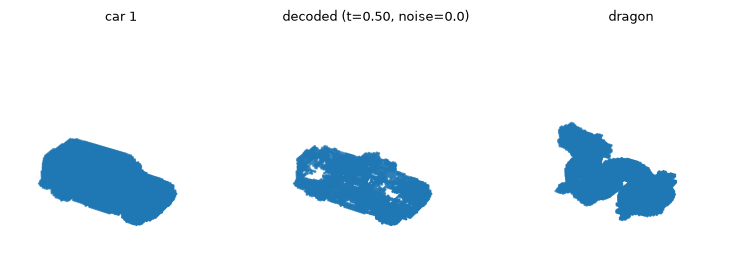

In [8]:
def explore(source: int, target: int, t: float, noise: float):
    z = (1.0 - t) * mu[source] + t * mu[target] + noise * torch.randn(sv.LATENT_DIM, device=device)
    decoded = decode_latents(z.unsqueeze(0))
    plot_grids(
        [
            (gt_grid, source, shape_names[source]),
            (decoded, 0, f"decoded (t={t:.2f}, noise={noise:.1f})"),
            (gt_grid, target, shape_names[target]),
        ]
    )


try:
    import ipywidgets

    shape_options = [(name, i) for i, name in enumerate(shape_names)]
    ipywidgets.interact(
        explore,
        source=ipywidgets.Dropdown(options=shape_options, value=0, description="from"),
        target=ipywidgets.Dropdown(options=shape_options, value=4, description="to"),
        t=ipywidgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5, description="blend"),
        noise=ipywidgets.FloatSlider(min=0.0, max=2.0, step=0.1, value=0.0, description="noise"),
    )
except ImportError:
    print("ipywidgets is not installed - showing a single static frame instead.")
    print("Install it (`pip install ipywidgets`) and re-run this cell for live sliders.")
    explore(source=0, target=4, t=0.5, noise=0.0)